In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt

class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.conv(x)


class UNetSimple(nn.Module):
    def __init__(self, in_ch=1, out_ch=1):
        super().__init__()

        # Encoder
        self.enc1 = DoubleConv(in_ch, 32)
        self.enc2 = DoubleConv(32, 64)
        self.enc3 = DoubleConv(64, 128)

        self.pool = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = DoubleConv(128, 256)

        # Decoder
        self.up3 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec3 = DoubleConv(256, 128)

        self.up2 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec2 = DoubleConv(128, 64)

        self.up1 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.dec1 = DoubleConv(64, 32)

        self.out_conv = nn.Conv2d(32, out_ch, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))

        b = self.bottleneck(self.pool(e3))

        d3 = self.up3(b)
        d3 = self.dec3(torch.cat([d3, e3], dim=1))

        d2 = self.up2(d3)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))

        d1 = self.up1(d2)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))

        return torch.sigmoid(self.out_conv(d1))

In [2]:
class ImageDataset(Dataset):
    def __init__(self, inputs_path, target_path, target_size=(512, 512)):
        self.inputs_path = inputs_path
        self.target_path = target_path
        self.target_size = target_size
        self.transform = transforms.ToTensor()

        # Load target once
        t_img = Image.open(self.target_path).convert('L')
        t_img = t_img.resize(self.target_size, Image.LANCZOS)
        self.target_tensor = self.transform(t_img)

    def __len__(self):
        return len(self.inputs_path)

    def __getitem__(self, index):
        x_path = self.inputs_path[index]
        x_image = Image.open(x_path).convert('L')
        x_image = x_image.resize(self.target_size, Image.LANCZOS)
        x_tensor = self.transform(x_image)
        y_tensor = self.target_tensor
        return x_tensor, y_tensor

In [3]:
import os

# Paths
inputs_path = [
    'quantom_dataset/train/train1.png',
    'quantom_dataset/train/train2.png',
    'quantom_dataset/train/train3.png'
]
target_path = 'quantom_dataset/target/ground_truth.png'

# Dataset and DataLoader
dataset = ImageDataset(inputs_path, target_path, target_size=(512, 512))
dataloader = DataLoader(dataset, batch_size=3, shuffle=False)

# Device and model
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = UNetSimple(in_ch=1, out_ch=1).to(device)

# Optimizer and loss
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.L1Loss()

print(f"Device: {device}")
print(f"Dataset size: {len(dataset)}")

Device: cuda
Dataset size: 3


In [4]:
model.train()
num_epochs = 2000
loss_history = []

from tqdm import tqdm

for epoch in tqdm(range(num_epochs)):
    epoch_losses = []
    
    current_loss = float('inf')
    patience = 50 
    patience_counter = 0

    for x, y in dataloader:
        x, y = x.to(device), y.to(device)
        
        optimizer.zero_grad()
        output = model(x)
        loss = criterion(output, y)
        
        epoch_losses.append(loss.item())
        loss.backward()
        optimizer.step()
    
    avg_loss = np.mean(epoch_losses)
    loss_history.append(avg_loss)

    if avg_loss < current_loss : 
        current_loss = avg_loss 
        torch.save({
            'model_state_dict': model.state_dict(),
            'loss_history': loss_history
        }, 'checkpoint.pth')
    else : 
        patience_counter +=1 
        if patience_counter >= patience : 
            print('early stop triggered')
            break 
    
    if (epoch + 1) % 50 == 0:
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.6f}")

# Save model
torch.save(model.state_dict(), 'simple_unet_model.pth')
print("Model saved!")

  2%|▎         | 50/2000 [00:15<09:45,  3.33it/s]

Epoch [50/2000], Loss: 0.121225


  5%|▌         | 100/2000 [00:30<09:32,  3.32it/s]

Epoch [100/2000], Loss: 0.101305


  8%|▊         | 150/2000 [00:45<09:18,  3.31it/s]

...

Epoch [1900/2000], Loss: 0.014476


 98%|█████████▊| 1950/2000 [09:58<00:14,  3.38it/s]

Epoch [1950/2000], Loss: 0.016364


100%|██████████| 2000/2000 [10:13<00:00,  3.26it/s]

Epoch [2000/2000], Loss: 0.014956
Model saved!


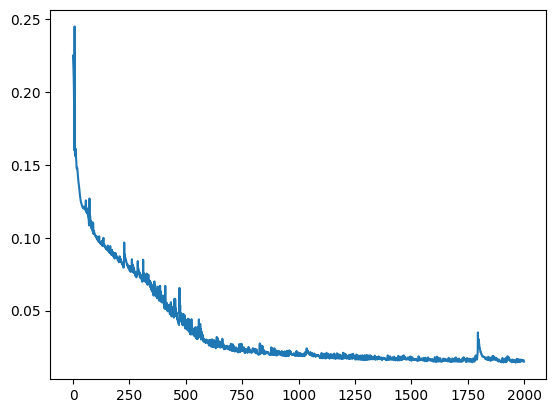

In [7]:
import matplotlib.pyplot as plt 
plt.plot(loss_history)

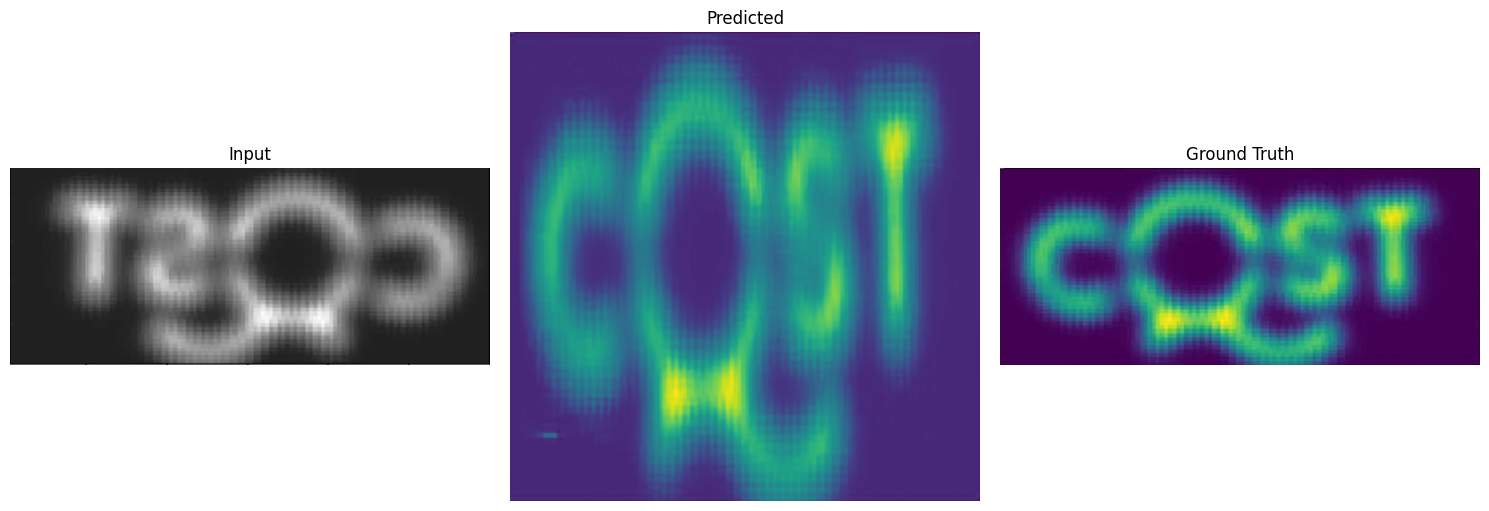

In [12]:
model.eval()

# Load a test image
test_img_path = inputs_path[1]  # or any training image
img = Image.open(test_img_path).convert('L')
img_resized = img.resize((512, 512), Image.LANCZOS)

# Preprocess
transform = transforms.ToTensor()
input_tensor = transform(img_resized).unsqueeze(0).to(device)

# Inference
with torch.no_grad():
    output = model(input_tensor)
    pred_np = output[0, 0].cpu().numpy()

# Load ground truth
gt_img = Image.open(target_path)

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img, cmap='gray')
axes[0].set_title('Input')
axes[0].axis('off')

axes[1].imshow(pred_np, cmap='viridis')
axes[1].set_title('Predicted')
axes[1].axis('off')

axes[2].imshow(gt_img)
axes[2].set_title('Ground Truth')
axes[2].axis('off')

plt.tight_layout()
plt.show()